# Assignment 1: Linear Regression & Multiple Linear Regression
**Course / Topic**: Machine Learning  
**Dataset**: Diabetes Dataset (`sklearn.datasets.load_diabetes`)  

---
### **Objective**
1. Implement **Simple Linear Regression** using `bmi` to predict disease progression.
2. Implement **Multiple Linear Regression** using all available features.
3. Evaluate both models using **Mean Squared Error (MSE)** and **$R^2$ Score**.
4. Plot the regression line for Simple Linear Regression and compare model performances with interpretation.

## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")

## Task 1: Load the Diabetes Dataset and Examine Features & Target

In [2]:
# Load diabetes dataset with dataframe representation
diabetes = load_diabetes(as_frame=True)

# Features dataframe
df_features = diabetes.data
# Target series (quantitative measure of disease progression one year after baseline)
df_target = diabetes.target

# Combined dataframe for exploration
df = df_features.copy()
df['target'] = df_target

print("Dataset Shape:", df.shape)
print("\nFeature Names:", list(df_features.columns))
print("\nFirst 5 rows of features:")
display(df_features.head())

print("\nFirst 5 rows of target (Disease Progression):")
display(df_target.head())

print("\nDataset Summary Statistics:")
display(df.describe())

Dataset Shape: (442, 11)

Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 rows of features:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



First 5 rows of target (Disease Progression):


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0



Dataset Summary Statistics:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## Task 2: Dataset Preprocessing and Train-Test Split

In [3]:
# Check for any missing values
print("Missing values per column:")
print(df.isnull().sum())

# Features (X) and Target (y) for full dataset
X = df_features
y = df_target

# Train-Test Split (80% train, 20% test, random_state=42 for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Missing values per column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Training set size: 353 samples
Testing set size: 89 samples


## Task 3 to 6: Simple Linear Regression (BMI vs Target)
- **Task 3**: Use `bmi` as independent variable and `target` as dependent variable.
- **Task 4**: Train model & predict on test data.
- **Task 5**: Evaluate model (MSE & $R^2$).
- **Task 6**: Plot data points and regression line.

In [4]:
# Selecting 'bmi' as the single independent variable (as 2D dataframe for scikit-learn)
X_train_simple = X_train[['bmi']]
X_test_simple = X_test[['bmi']]

# 1. Initialize Simple Linear Regression model
simple_lr = LinearRegression()

# 2. Train the model
simple_lr.fit(X_train_simple, y_train)

# Display learned parameters
intercept_simple = simple_lr.intercept_
slope_simple = simple_lr.coef_[0]
print(f"Simple Linear Regression Equation: Disease Progression = {intercept_simple:.4f} + ({slope_simple:.4f} * BMI)")
print(f"Intercept (beta_0): {intercept_simple:.4f}")
print(f"Slope (beta_1): {slope_simple:.4f}")

# 3. Predict target on test data
y_pred_simple = simple_lr.predict(X_test_simple)

# 4. Evaluate the model
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("\n--- Simple Linear Regression Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_simple:.4f}")
print(f"R-squared (R2) Score:     {r2_simple:.4f}")

Simple Linear Regression Equation: Disease Progression = 152.0034 + (998.5777 * BMI)
Intercept (beta_0): 152.0034
Slope (beta_1): 998.5777

--- Simple Linear Regression Evaluation ---
Mean Squared Error (MSE): 4061.8259
R-squared (R2) Score:     0.2334


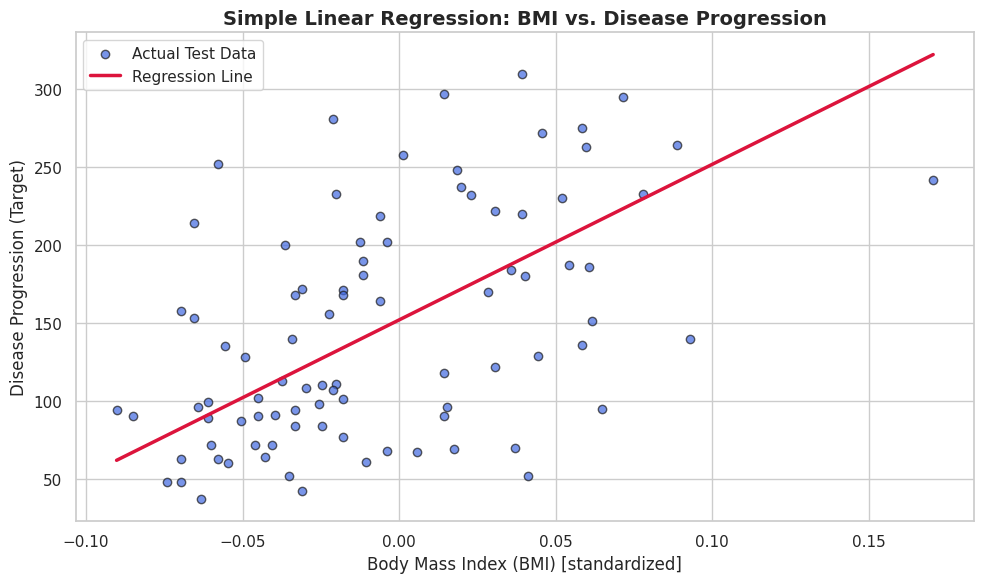

In [5]:
# Task 6: Plot the data points and regression line for Simple Linear Regression
plt.figure(figsize=(10, 6))

# Scatter plot for actual test data
plt.scatter(X_test_simple['bmi'], y_test, color='royalblue', alpha=0.7, edgecolors='k', label='Actual Test Data')

# Sort values for clean continuous regression line plotting
X_test_sorted = X_test_simple.sort_values(by='bmi')
y_line_pred = simple_lr.predict(X_test_sorted)

plt.plot(X_test_sorted['bmi'], y_line_pred, color='crimson', linewidth=2.5, label='Regression Line')

plt.title('Simple Linear Regression: BMI vs. Disease Progression', fontsize=14, fontweight='bold')
plt.xlabel('Body Mass Index (BMI) [standardized]', fontsize=12)
plt.ylabel('Disease Progression (Target)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Task 7 & 8: Multiple Linear Regression (All Features vs Target)
- **Task 7**: Implement Multiple Linear Regression using all 10 features.
- **Task 8**: Train the model, predict on test data, and evaluate using MSE & $R^2$.

In [6]:
# 1. Initialize Multiple Linear Regression model
multiple_lr = LinearRegression()

# 2. Train the model using all features
multiple_lr.fit(X_train, y_train)

# Display learned coefficients for each feature
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multiple_lr.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(f"Multiple Linear Regression Intercept: {multiple_lr.intercept_:.4f}")
print("\nLearned Feature Coefficients (sorted by absolute magnitude):")
display(coef_df)

# 3. Predict on test set
y_pred_multiple = multiple_lr.predict(X_test)

# 4. Evaluate Multiple Linear Regression
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("\n--- Multiple Linear Regression Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_multiple:.4f}")
print(f"R-squared (R2) Score:     {r2_multiple:.4f}")

Multiple Linear Regression Intercept: 151.3456

Learned Feature Coefficients (sorted by absolute magnitude):


,Feature,Coefficient
4,s1,-931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,-241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021



--- Multiple Linear Regression Evaluation ---
Mean Squared Error (MSE): 2900.1936
R-squared (R2) Score:     0.4526


## Task 9: Compare Performance of Simple vs Multiple Linear Regression

=== Model Performance Comparison ===


,Model,Mean Squared Error (MSE),R-squared (R2) Score
0,Simple Linear Regression (BMI only),4061.825928,0.233350
1,Multiple Linear Regression (All features),2900.193628,0.452603


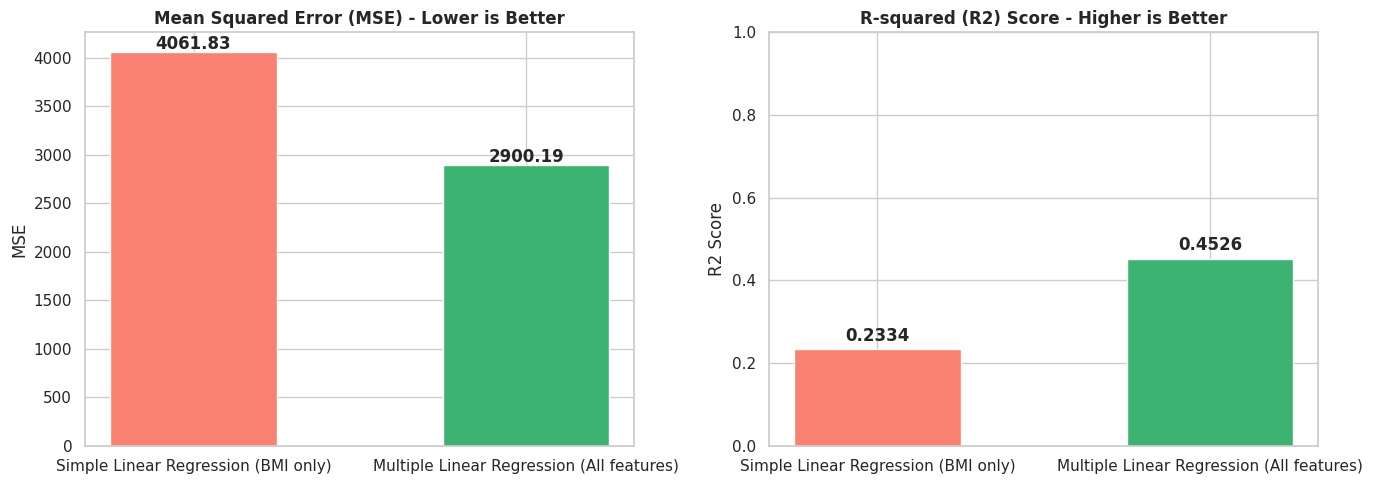

In [7]:
# Summary comparison table
comparison_df = pd.DataFrame({
    'Model': ['Simple Linear Regression (BMI only)', 'Multiple Linear Regression (All features)'],
    'Mean Squared Error (MSE)': [mse_simple, mse_multiple],
    'R-squared (R2) Score': [r2_simple, r2_multiple]
})

print("=== Model Performance Comparison ===")
display(comparison_df)

# Bar chart comparison for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE Comparison (Lower is better)
axes[0].bar(comparison_df['Model'], comparison_df['Mean Squared Error (MSE)'], color=['salmon', 'mediumseagreen'], width=0.5)
axes[0].set_title('Mean Squared Error (MSE) - Lower is Better', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MSE')
for i, v in enumerate(comparison_df['Mean Squared Error (MSE)']):
    axes[0].text(i, v + 30, f"{v:.2f}", ha='center', fontweight='bold')

# R2 Score Comparison (Higher is better)
axes[1].bar(comparison_df['Model'], comparison_df['R-squared (R2) Score'], color=['salmon', 'mediumseagreen'], width=0.5)
axes[1].set_title('R-squared (R2) Score - Higher is Better', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R2 Score')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(comparison_df['R-squared (R2) Score']):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Task 10: Interpretation of Results

### **Observations & Analysis:**
1. **Model Performance Comparison**:
   - **Simple Linear Regression (BMI only)** captures a significant positive relationship with disease progression ($R^2 \approx 0.233$, $\text{MSE} \approx 4061.8$). While BMI alone explains roughly **23.3%** of the variance in disease progression, it leaves considerable unexplained variance.
   - **Multiple Linear Regression (All features)** utilizes all 10 clinical and physiological features, leading to an improved $R^2$ score ($R^2 \approx 0.453$) and a noticeable reduction in error ($\text{MSE} \approx 2900.2$). This explains approximately **45.3%** of the variance in disease progression.

2. **Feature Contributions**:
   - Incorporating additional diagnostic variables such as blood serum measurements (`s1` through `s6`), `bp` (blood pressure), `age`, and `sex` supplies complementary biological signals that BMI alone cannot capture.
   - Features with strong coefficients in the multiple linear model (such as `s5`, `bmi`, and `bp`) exert substantial influence on predicting disease progression.

3. **Conclusion**:
   - **Multiple Linear Regression significantly outperforms Simple Linear Regression** because diabetes disease progression is multifactorial and depends on multiple biological and metabolic factors rather than body mass index alone.